In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

In [6]:
def _print_stats(label, arr):
    print(f"\n[{label}]")
    print(f"  Mean : {np.mean(arr):.2f} ms")
    print(f"  P50  : {np.percentile(arr, 50):.2f} ms")
    print(f"  P95  : {np.percentile(arr, 95):.2f} ms")
    print(f"  Max  : {np.max(arr):.2f} ms")


def _plot_latency_pair(net_arr, fft_arr, title_suffix):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    axes[0].hist(net_arr, bins=50, color='royalblue', edgecolor='black', alpha=0.7)
    axes[0].axvline(np.mean(net_arr), color='red', linestyle='dashed', linewidth=1, label=f'Mean: {np.mean(net_arr):.2f} ms')
    axes[0].axvline(np.percentile(net_arr, 50), color='orange', linestyle='dashed', linewidth=1, label=f'P50: {np.percentile(net_arr, 50):.2f} ms')
    axes[0].axvline(np.percentile(net_arr, 95), color='green', linestyle='dashed', linewidth=1, label=f'P95: {np.percentile(net_arr, 95):.2f} ms')
    axes[0].set_title(f'Network & Kafka Pipeline Latency{title_suffix}')
    axes[0].set_xlabel('Latency (ms)')
    axes[0].set_ylabel('Frequency (Number of Packets)')
    axes[0].grid(axis='y', alpha=0.75)
    axes[0].legend()

    axes[1].hist(fft_arr, bins=50, color='seagreen', edgecolor='black', alpha=0.7)
    axes[1].axvline(np.mean(fft_arr), color='red', linestyle='dashed', linewidth=1, label=f'Mean: {np.mean(fft_arr):.2f} ms')
    axes[1].axvline(np.percentile(fft_arr, 50), color='orange', linestyle='dashed', linewidth=1, label=f'P50: {np.percentile(fft_arr, 50):.2f} ms')
    axes[1].axvline(np.percentile(fft_arr, 95), color='green', linestyle='dashed', linewidth=1, label=f'P95: {np.percentile(fft_arr, 95):.2f} ms')
    axes[1].set_title(f'Dask Worker FFT Computation Latency{title_suffix}')
    axes[1].set_xlabel('Latency (ms)')
    axes[1].set_ylabel('Frequency (Number of Packets)')
    axes[1].grid(axis='y', alpha=0.75)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def plot_benchmarks(file, per_worker=True):
    try:
        with open(file, "r") as f:
            run = json.load(f)
    except FileNotFoundError:
        print(f"Error: {file} not found. Run the pipeline first!")
        return

    # Group records by worker, preserving the order they appear in "data"
    # (this order matches the position in that worker's receive_tss array).
    records_by_worker = defaultdict(list)
    for rec in run["data"]:
        records_by_worker[rec["worker_id"]].append(rec)

    net_by_worker = {}
    fft_by_worker = {}
    scans_by_worker = {}

    all_net_latencies = []
    all_fft_latencies = []

    for w_id, records in records_by_worker.items():
        recv_tss = records[0]["receive_tss"]  # identical across all records of this worker

        w_net, w_fft = [], []
        total_scans = 0

        for i, rec in enumerate(records):
            total_scans += rec["n_averaged_scans"]

            receive_ts = recv_tss[i]
            for prod_ts in rec["production_tss"]:
                w_net.append((receive_ts - prod_ts) * 1000)

            w_fft.extend(rec["fft_latencies_ms"])

        net_by_worker[w_id] = np.array(w_net)
        fft_by_worker[w_id] = np.array(w_fft)
        scans_by_worker[w_id] = total_scans

        all_net_latencies.extend(w_net)
        all_fft_latencies.extend(w_fft)

    if not all_net_latencies:
        print("No latency data found in the file.")
        return

    net_arr = np.array(all_net_latencies)
    fft_arr = np.array(all_fft_latencies)

    print("\n" + "="*40)
    print("        BENCHMARK RESULTS")
    print("="*40)
    print(f"Throughput target : {run['throughput'] / 1e6:.2f} MB/s")
    print(f"Scans per batch    : {run['n_scans_per_batch']}")
    print(f"Analysis time      : {run['analysis_time']:.1f} s")
    print(f"Total packets analyzed: {len(net_arr)}")
    for w_id, scans in scans_by_worker.items():
        print(f"  - worker {w_id} processed {scans} scans")

    _print_stats("Network + Kafka Latency (all workers)", net_arr)
    _print_stats("FFT Computation Latency (all workers)", fft_arr)
    print("="*40)

    # Aggregate plot (all workers combined)
    _plot_latency_pair(net_arr, fft_arr, title_suffix="")

    # Per-worker plots
    if per_worker:
        for w_id in sorted(records_by_worker):
            print("\n" + "-"*40)
            print(f"        WORKER {w_id}")
            print("-"*40)
            _print_stats(f"Network + Kafka Latency (worker {w_id})", net_by_worker[w_id])
            _print_stats(f"FFT Computation Latency (worker {w_id})", fft_by_worker[w_id])
            _plot_latency_pair(net_by_worker[w_id], fft_by_worker[w_id], title_suffix=f" — Worker {w_id}")


        BENCHMARK RESULTS
Throughput target : 16.78 MB/s
Scans per batch    : 1024
Analysis time      : 145.6 s
Total packets analyzed: 124
  - worker 2 processed 36864 scans
  - worker 1 processed 43008 scans
  - worker 3 processed 47104 scans

[Network + Kafka Latency (all workers)]
  Mean : 11590.20 ms
  P50  : 10040.24 ms
  P95  : 25228.02 ms
  Max  : 32994.40 ms

[FFT Computation Latency (all workers)]
  Mean : 61.79 ms
  P50  : 68.59 ms
  P95  : 80.75 ms
  Max  : 110.66 ms


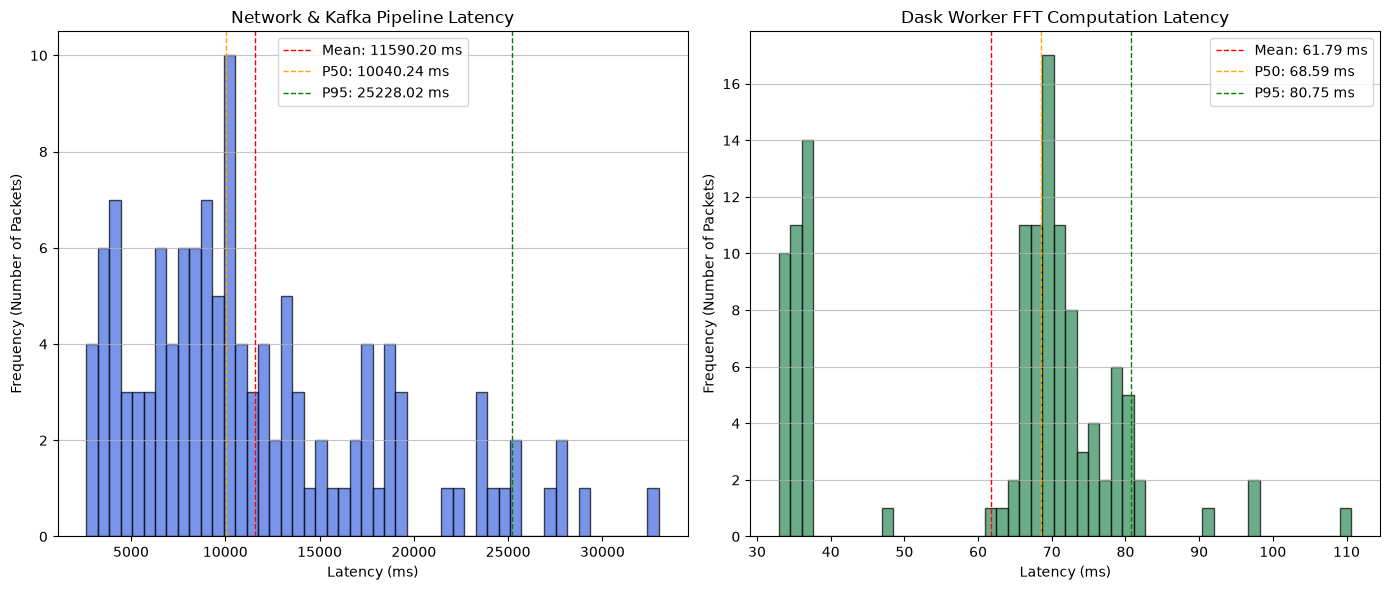


----------------------------------------
        WORKER 1
----------------------------------------

[Network + Kafka Latency (worker 1)]
  Mean : 10390.92 ms
  P50  : 10040.24 ms
  P95  : 17035.96 ms
  Max  : 18381.45 ms

[FFT Computation Latency (worker 1)]
  Mean : 75.46 ms
  P50  : 74.71 ms
  P95  : 97.67 ms
  Max  : 110.66 ms


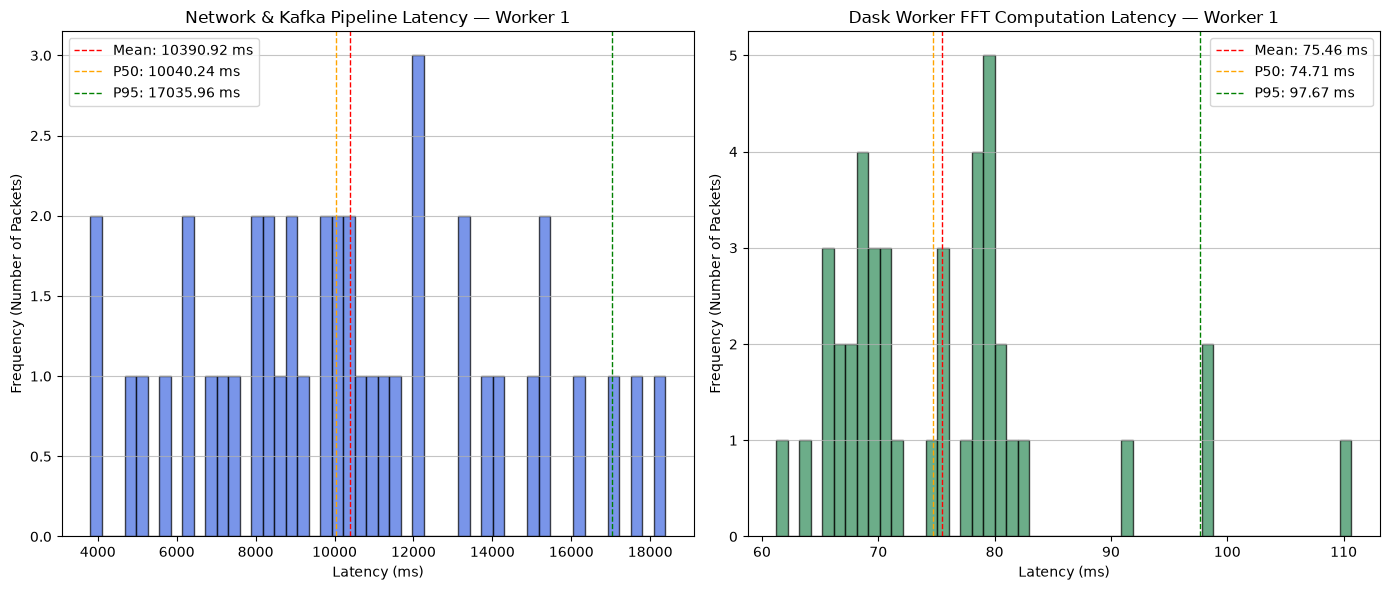


----------------------------------------
        WORKER 2
----------------------------------------

[Network + Kafka Latency (worker 2)]
  Mean : 6335.21 ms
  P50  : 5822.98 ms
  P95  : 10984.93 ms
  Max  : 12489.46 ms

[FFT Computation Latency (worker 2)]
  Mean : 35.57 ms
  P50  : 35.28 ms
  P95  : 37.00 ms
  Max  : 47.68 ms


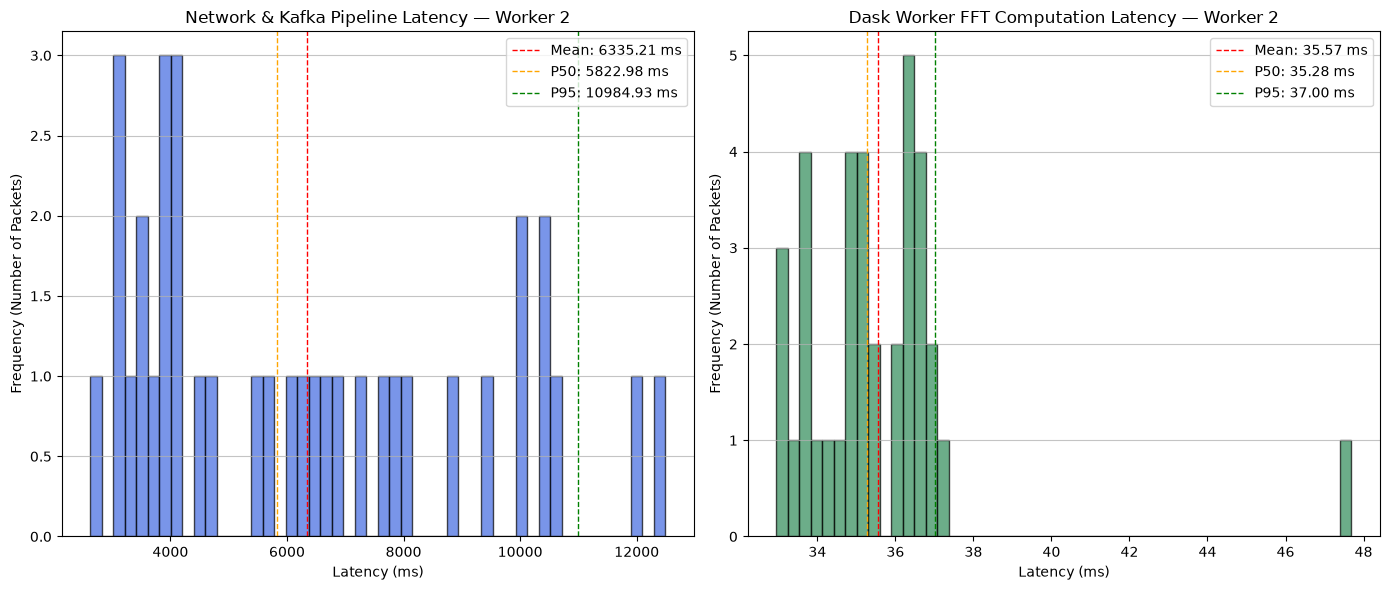


----------------------------------------
        WORKER 3
----------------------------------------

[Network + Kafka Latency (worker 3)]
  Mean : 16797.80 ms
  P50  : 17283.21 ms
  P95  : 27976.28 ms
  Max  : 32994.40 ms

[FFT Computation Latency (worker 3)]
  Mean : 69.84 ms
  P50  : 69.73 ms
  P95  : 73.62 ms
  Max  : 76.57 ms


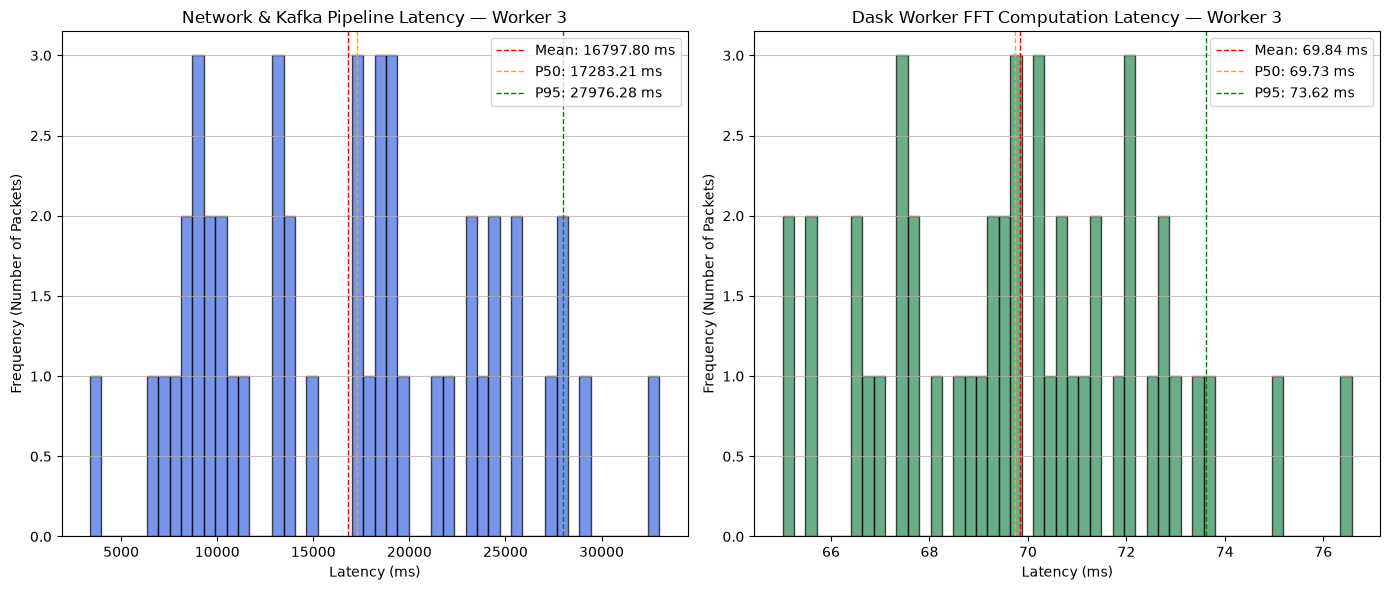

In [7]:
plot_benchmarks("benchmark/3worker_scan1024.json")


        BENCHMARK RESULTS
Throughput target : 16.78 MB/s
Scans per batch    : 2048
Analysis time      : 129.3 s
Total packets analyzed: 62
  - worker 2 processed 57344 scans
  - worker 1 processed 32768 scans
  - worker 3 processed 36864 scans

[Network + Kafka Latency (all workers)]
  Mean : 13498.64 ms
  P50  : 12917.09 ms
  P95  : 22887.97 ms
  Max  : 27689.30 ms

[FFT Computation Latency (all workers)]
  Mean : 104.76 ms
  P50  : 134.07 ms
  P95  : 142.41 ms
  Max  : 145.45 ms


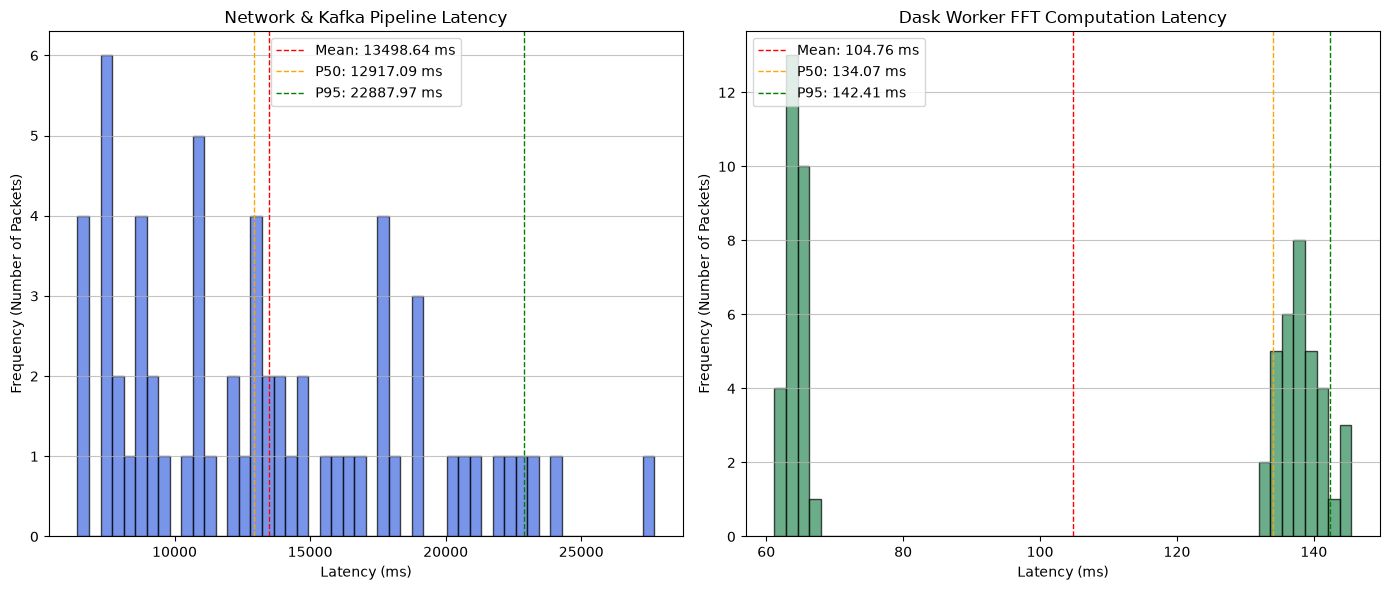


----------------------------------------
        WORKER 1
----------------------------------------

[Network + Kafka Latency (worker 1)]
  Mean : 10552.41 ms
  P50  : 9596.19 ms
  P95  : 16032.67 ms
  Max  : 17632.44 ms

[FFT Computation Latency (worker 1)]
  Mean : 137.19 ms
  P50  : 136.43 ms
  P95  : 143.16 ms
  Max  : 145.33 ms


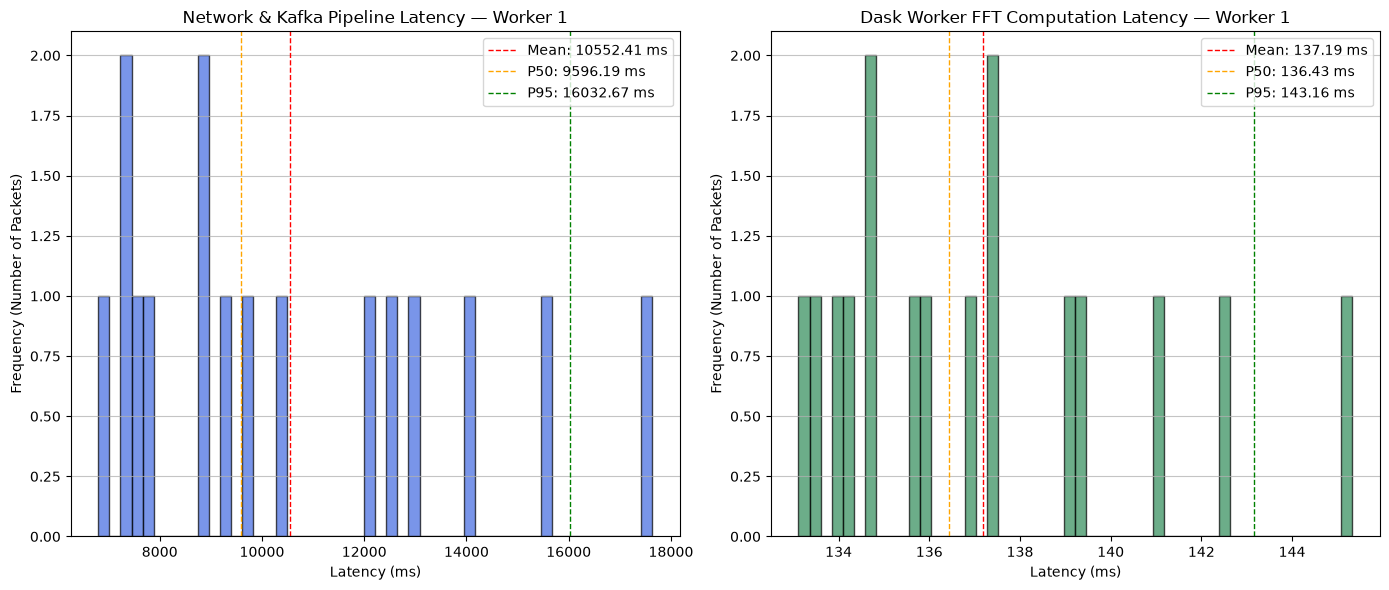


----------------------------------------
        WORKER 2
----------------------------------------

[Network + Kafka Latency (worker 2)]
  Mean : 16713.88 ms
  P50  : 17277.11 ms
  P95  : 23864.01 ms
  Max  : 27689.30 ms

[FFT Computation Latency (worker 2)]
  Mean : 64.18 ms
  P50  : 64.49 ms
  P95  : 65.81 ms
  Max  : 66.65 ms


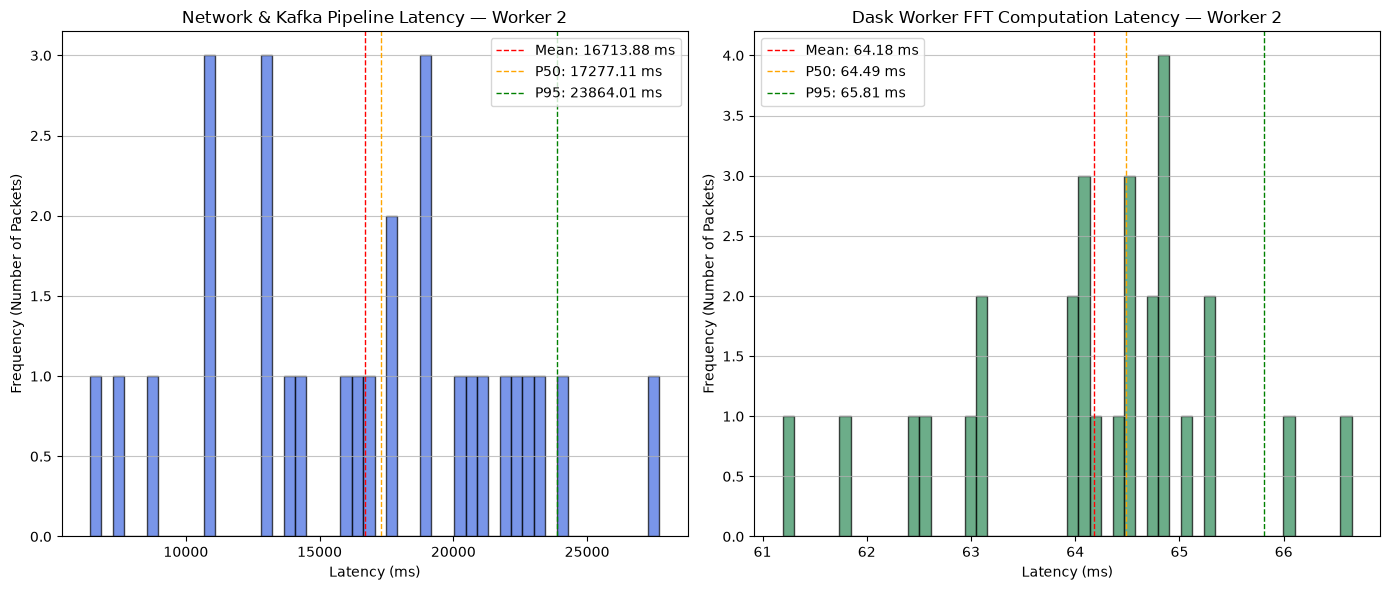


----------------------------------------
        WORKER 3
----------------------------------------

[Network + Kafka Latency (worker 3)]
  Mean : 11116.03 ms
  P50  : 10929.89 ms
  P95  : 17787.51 ms
  Max  : 17926.66 ms

[FFT Computation Latency (worker 3)]
  Mean : 139.06 ms
  P50  : 138.32 ms
  P95  : 144.83 ms
  Max  : 145.45 ms


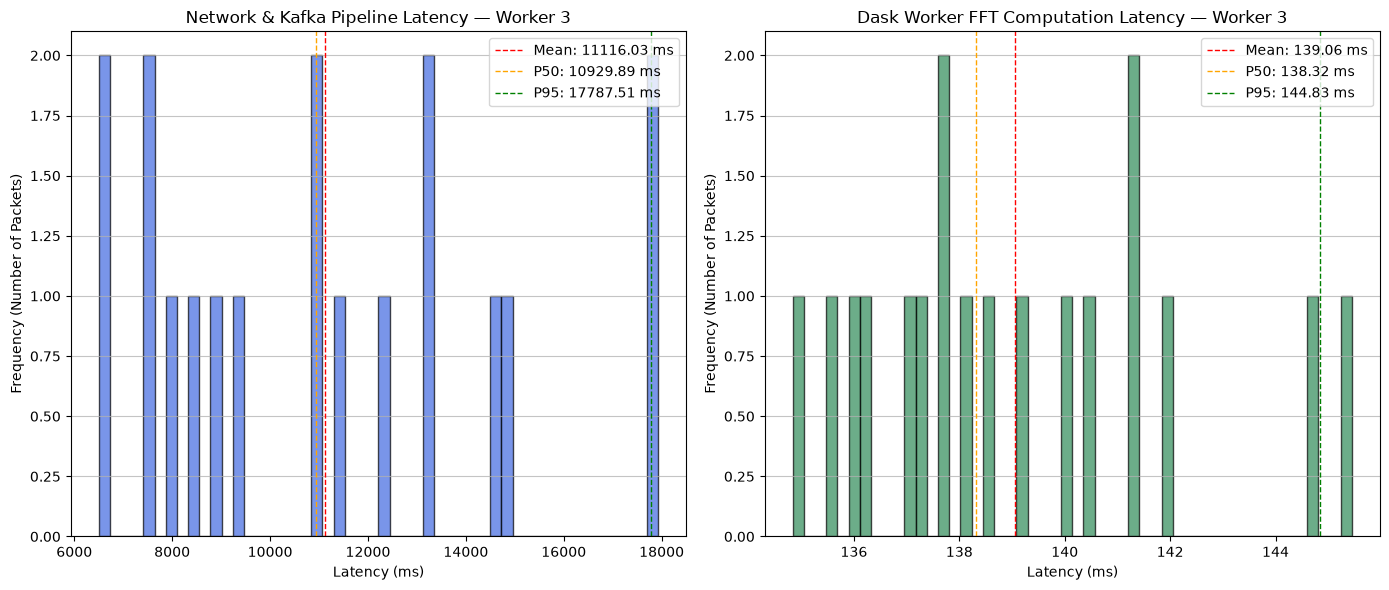

In [18]:
plot_benchmarks("benchmark/3worker_scan2048_2.json")


        BENCHMARK RESULTS
Throughput target : 16.78 MB/s
Scans per batch    : 4096
Analysis time      : 141.7 s
Total packets analyzed: 30
  - worker 3 processed 32768 scans
  - worker 2 processed 45056 scans
  - worker 1 processed 45056 scans

[Network + Kafka Latency (all workers)]
  Mean : 22820.28 ms
  P50  : 15267.77 ms
  P95  : 48605.80 ms
  Max  : 50725.65 ms

[FFT Computation Latency (all workers)]
  Mean : 228.33 ms
  P50  : 275.47 ms
  P95  : 347.62 ms
  Max  : 390.43 ms


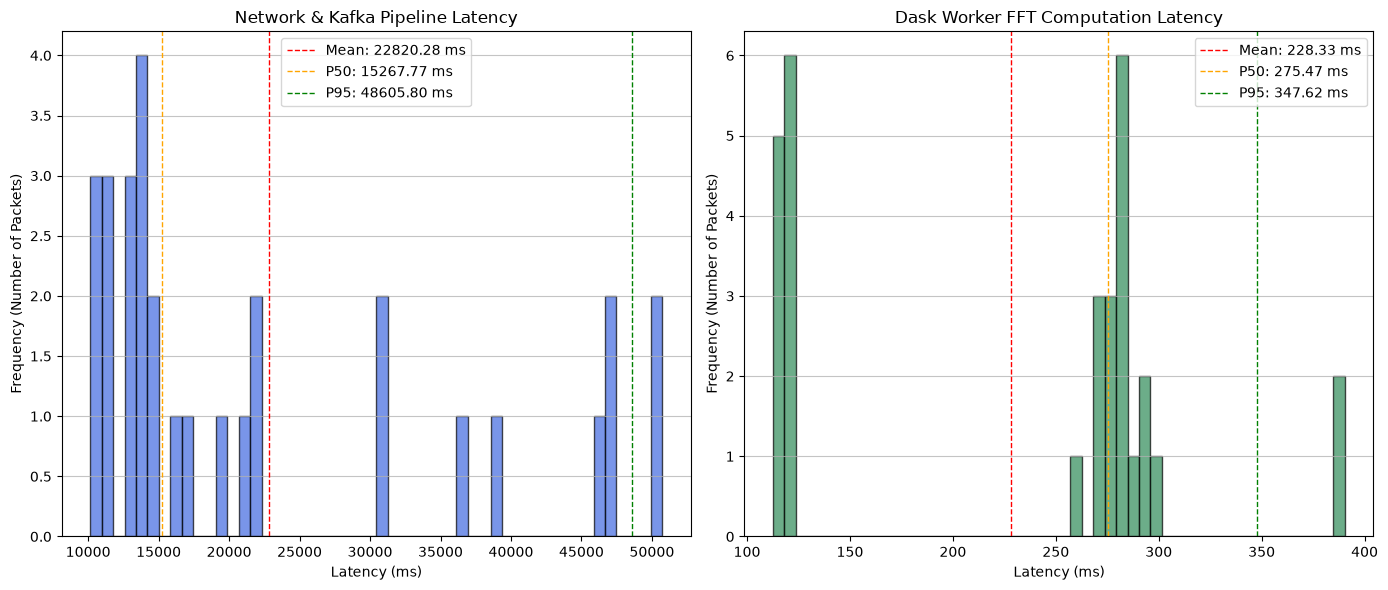


----------------------------------------
        WORKER 1
----------------------------------------

[Network + Kafka Latency (worker 1)]
  Mean : 36800.71 ms
  P50  : 38570.28 ms
  P95  : 50327.10 ms
  Max  : 50725.65 ms

[FFT Computation Latency (worker 1)]
  Mean : 305.08 ms
  P50  : 289.17 ms
  P95  : 389.34 ms
  Max  : 390.43 ms


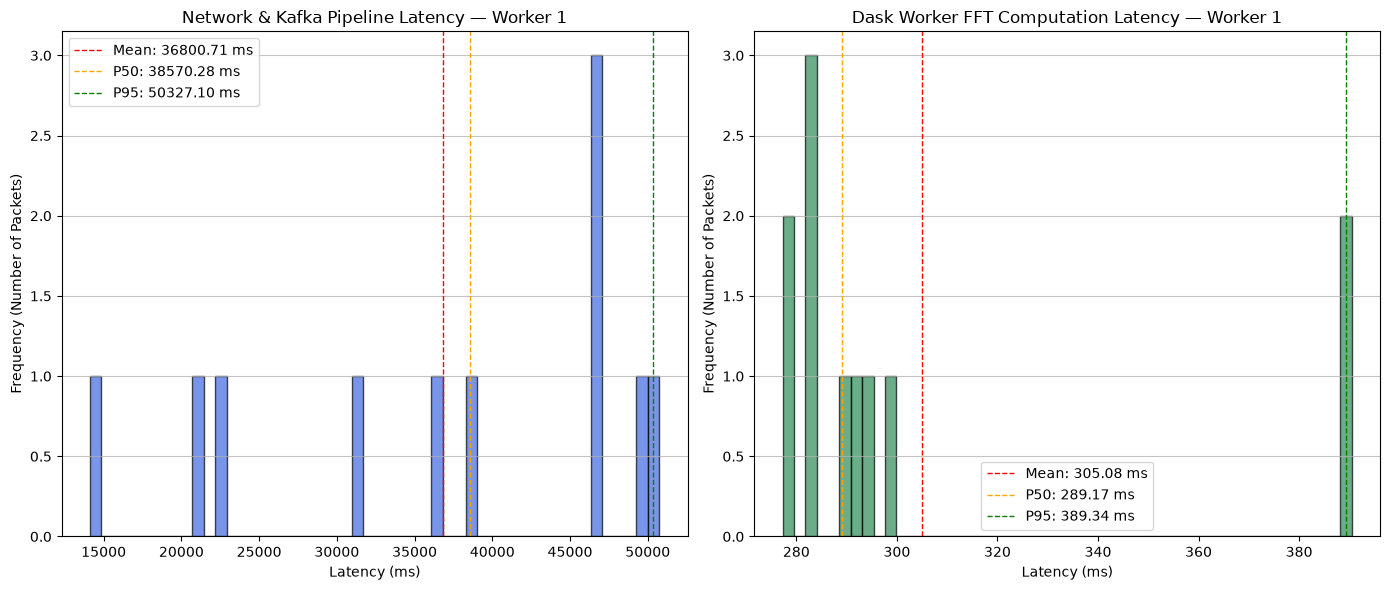


----------------------------------------
        WORKER 2
----------------------------------------

[Network + Kafka Latency (worker 2)]
  Mean : 13097.42 ms
  P50  : 11724.40 ms
  P95  : 18084.20 ms
  Max  : 19096.62 ms

[FFT Computation Latency (worker 2)]
  Mean : 117.78 ms
  P50  : 118.69 ms
  P95  : 122.18 ms
  Max  : 122.79 ms


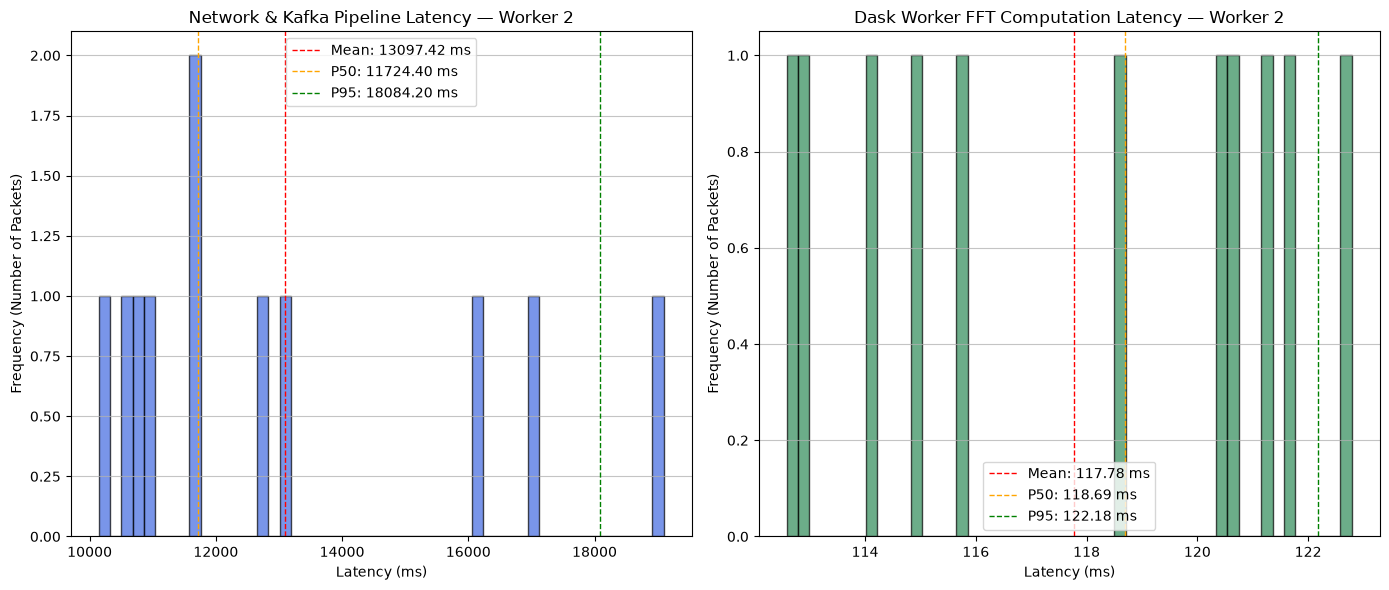


----------------------------------------
        WORKER 3
----------------------------------------

[Network + Kafka Latency (worker 3)]
  Mean : 16966.13 ms
  P50  : 14058.98 ms
  P95  : 27791.25 ms
  Max  : 30882.17 ms

[FFT Computation Latency (worker 3)]
  Mean : 274.79 ms
  P50  : 275.63 ms
  P95  : 281.76 ms
  Max  : 283.02 ms


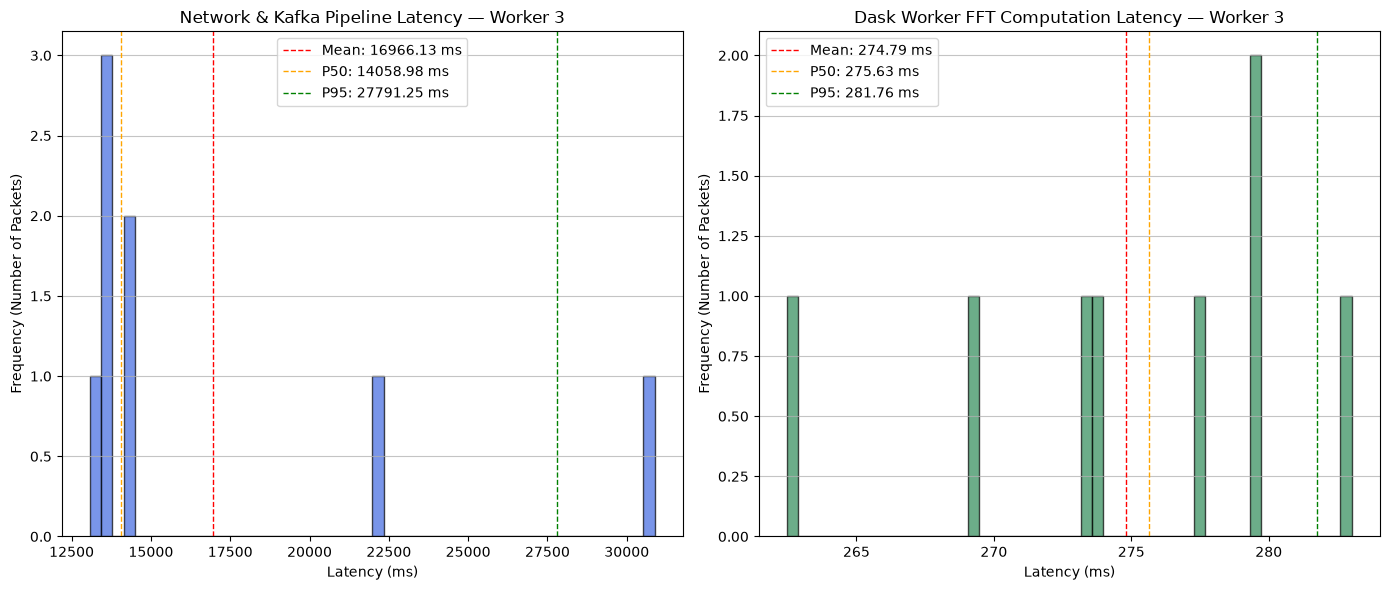

In [16]:
plot_benchmarks("benchmark/3worker_scan4096.json")

In [22]:
BYTES_PER_SCAN = 2 * 4 * 2048  # I + Q, float32, SAMPLES_PER_SCAN=2048 -> 16384 B/scan


def _load_run(file):
    with open(file, "r") as f:
        run = json.load(f)

    records_by_worker = defaultdict(list)
    for rec in run["data"]:
        records_by_worker[rec["worker_id"]].append(rec)

    return run, records_by_worker


# =============================================================================
# Plot 1: latency vs time, per worker -- to check queue stability
# =============================================================================
def plot_latency_stability(file):
    run, records_by_worker = _load_run(file)

    fig, axes = plt.subplots(1, len(records_by_worker), figsize=(6 * len(records_by_worker), 5), sharey=True)
    if len(records_by_worker) == 1:
        axes = [axes]

    for ax, w_id in zip(axes, sorted(records_by_worker)):
        records = records_by_worker[w_id]
        recv_tss = records[0]["receive_tss"]

        t0 = recv_tss[0]
        times, latencies = [], []

        for i, rec in enumerate(records):
            receive_ts = recv_tss[i]
            for prod_ts in rec["production_tss"]:
                times.append(receive_ts - t0)
                latencies.append((receive_ts - prod_ts) * 1000)

        times = np.array(times)
        latencies = np.array(latencies)

        ax.scatter(times, latencies, s=15, alpha=0.6, color='royalblue')

        # linear fit to quantify the trend (ms of latency gained per second of run)
        slope, intercept = np.polyfit(times, latencies, 1)
        fit_line = slope * times + intercept
        ax.plot(times, fit_line, color='red', linewidth=2,
                 label=f'slope: {slope:.1f} ms/s')

        status = "UNSTABLE (queue growing)" if slope > 5 else "stable"
        ax.set_title(f'Worker {w_id} — {status}')
        ax.set_xlabel('Elapsed time since run start (s)')
        ax.grid(alpha=0.4)
        ax.legend()

    axes[0].set_ylabel('Network + Kafka Latency (ms)')
    fig.suptitle(f'Latency stability over time (scans_per_batch={run["n_scans_per_batch"]})')
    plt.tight_layout()
    plt.show()

    return {w_id: np.polyfit(
        [records_by_worker[w_id][0]["receive_tss"][i] - records_by_worker[w_id][0]["receive_tss"][0]
         for i, rec in enumerate(records_by_worker[w_id]) for _ in rec["production_tss"]],
        [(records_by_worker[w_id][0]["receive_tss"][i] - prod_ts) * 1000
         for i, rec in enumerate(records_by_worker[w_id]) for prod_ts in rec["production_tss"]],
        1)[0]
        for w_id in records_by_worker}


# =============================================================================
# Plot 2: achieved throughput vs target, per worker and total
# =============================================================================
def plot_throughput(file):
    run, records_by_worker = _load_run(file)
    analysis_time = run["analysis_time"]
    target_throughput_MBs = run["throughput"] / (1024 * 1024) 

    scans_by_worker = {
        w_id: sum(rec["n_averaged_scans"] for rec in records)
        for w_id, records in records_by_worker.items()
    }
    total_scans = sum(scans_by_worker.values())

    achieved_total_MBs = (total_scans * BYTES_PER_SCAN) / analysis_time / (1024 * 1024)
    achieved_by_worker_MBs = {
        w_id: (scans * BYTES_PER_SCAN) / analysis_time / (1024 * 1024)
        for w_id, scans in scans_by_worker.items()
    }

    labels = ['Total'] + [f'Worker {w_id}' for w_id in sorted(scans_by_worker)]
    achieved = [achieved_total_MBs] + [achieved_by_worker_MBs[w] for w in sorted(scans_by_worker)]

    fig, ax = plt.subplots(figsize=(8, 5))
    x = np.arange(len(labels))
    bars = ax.bar(x, achieved, color='seagreen', edgecolor='black', alpha=0.8, label='Achieved throughput')
    ax.axhline(target_throughput_MBs, color='red', linestyle='dashed', linewidth=2,
               label=f'Target: {target_throughput_MBs:.2f} MB/s')

    for bar, val in zip(bars, achieved):
        ax.text(bar.get_x() + bar.get_width() / 2, val, f'{val:.2f}',
                ha='center', va='bottom', fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel('Throughput (MB/s)')
    ax.set_title(f'Achieved vs target throughput (scans_per_batch={run["n_scans_per_batch"]})')
    ax.grid(axis='y', alpha=0.4)
    ax.legend()
    plt.tight_layout()
    plt.show()

    print(f"Target throughput   : {target_throughput_MBs:.2f} MB/s")
    print(f"Achieved throughput : {achieved_total_MBs:.2f} MB/s "
          f"({100 * achieved_total_MBs / target_throughput_MBs:.1f}% of target)")

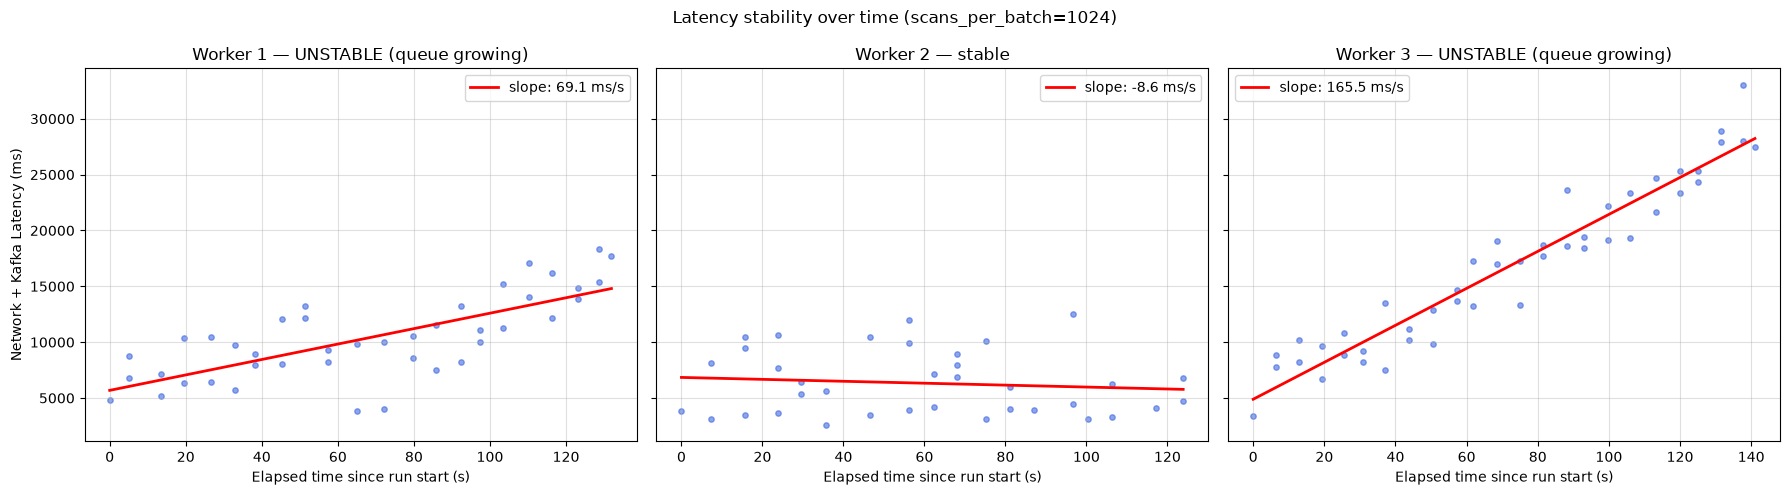

{2: np.float64(-8.622479294434175),
 1: np.float64(69.07257189314774),
 3: np.float64(165.48522172932584)}

In [20]:
plot_latency_stability("benchmark/3worker_scan1024.json")

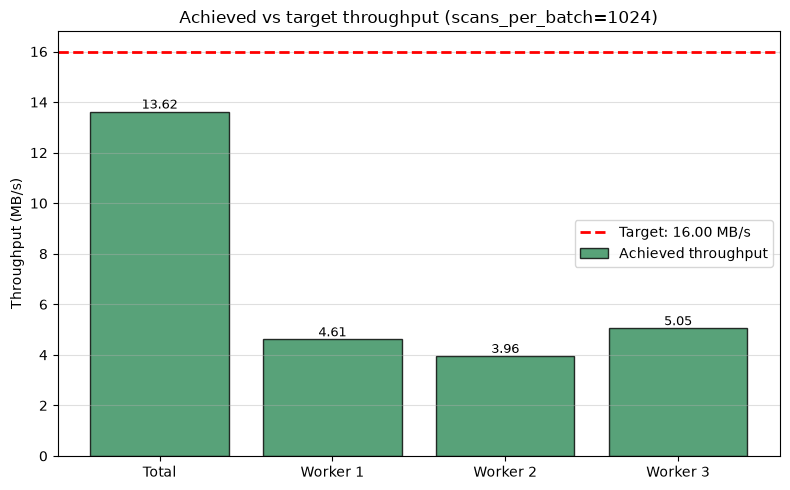

Target throughput   : 16.00 MB/s
Achieved throughput : 13.62 MB/s (85.2% of target)


In [23]:
plot_throughput("benchmark/3worker_scan1024.json")